# DriveValue AI: Exploratory Data Analysis (EDA)

## Capstone Project

**Author:** Jacqualine Makgolana

---

## Purpose

The purpose of this notebook is to explore the cleaned used car dataset and identify the key factors that influence vehicle asking prices.

The insights gained from this analysis will guide feature engineering, model development, and business recommendations.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../Data/processed/used_cars_cleaned.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,98000.0,NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,NaN,NaN,15.0,190000.0,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 14,988
Columns: 11
<class 'pandas.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         12347 non-null  str    
 1   model         9755 non-null   str    
 2   Year          11688 non-null  float64
 3   Age           11995 non-null  float64
 4   kmDriven      11840 non-null  float64
 5   Transmission  12018 non-null  str    
 6   Owner         9659 non-null   str    
 7   FuelType      12359 non-null  str    
 8   PostedDate    11867 non-null  str    
 9   AdditionInfo  14988 non-null  str    
 10  AskPrice      14988 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 1.3 MB


# Question 1

## How are used car asking prices distributed?

Understanding the distribution of asking prices helps identify the typical price range of used vehicles, detect skewness, and identify potential outliers that may influence machine learning model performance.

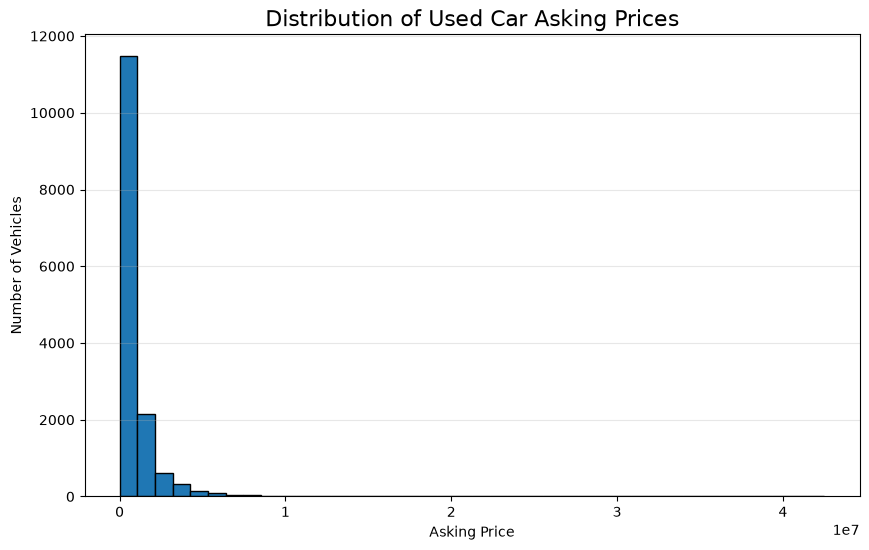

In [4]:
plt.figure(figsize=(10,6))

plt.hist(
    df["AskPrice"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Used Car Asking Prices", fontsize=16)
plt.xlabel("Asking Price")
plt.ylabel("Number of Vehicles")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [5]:
df["AskPrice"].describe()

count    1.498800e+04
mean     9.968848e+05
std      1.586835e+06
min      1.500000e+04
25%      3.490000e+05
50%      5.700000e+05
75%      1.025000e+06
max      4.250000e+07
Name: AskPrice, dtype: float64

In [7]:
print(f"Skewness: {df['AskPrice'].skew():.2f}")

Skewness: 8.12


### Interpretation

The distribution of used car asking prices is highly positively (right) skewed. Most vehicles are listed within the lower and middle price ranges, while only a small proportion of luxury vehicles have exceptionally high asking prices.

The summary statistics support this observation. The mean asking price (₹996,885) is substantially higher than the median (₹570,000), and the skewness coefficient of **8.12** confirms a highly right-skewed distribution. This indicates the presence of extreme high-value vehicles that influence the overall distribution.

### Insight

The used car market represented in this dataset is dominated by affordable and mid-range vehicles, while luxury vehicles make up only a small proportion of listings.

The strong positive skew (8.12) suggests that extreme vehicle prices could disproportionately influence predictive models. During the modelling phase, techniques such as target transformation and robust regression models will be considered to improve prediction performance.

# Question 2

## Which vehicle brands have the highest median asking prices?

Different vehicle manufacturers target different market segments. Comparing the median asking price across brands helps identify premium brands and understand how brand reputation influences resale value.

In [8]:
brand_price = (
    df.groupby("Brand")["AskPrice"]
      .median()
      .sort_values(ascending=False)
      .head(15)
)

brand_price

Brand
Rolls-Royce      42500000.0
Lamborghini      39000000.0
Bentley          18500000.0
Hummer            9800000.0
Maserati          8000000.0
Porsche           8000000.0
Toyota Land       7100000.0
Lexus             4650000.0
Land Rover        3924999.5
Mini              3300000.0
Jaguar            2440000.0
Mercedes-Benz     2200000.0
BMW               2099999.0
Citroen           1950000.0
Volvo             1775000.0
Name: AskPrice, dtype: float64

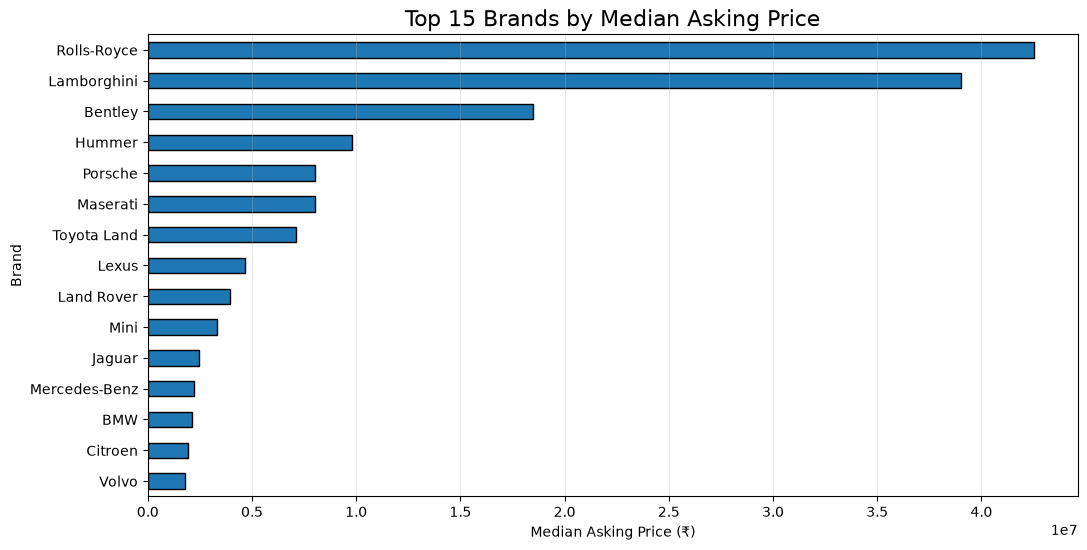

In [9]:
plt.figure(figsize=(12,6))

brand_price.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 15 Brands by Median Asking Price", fontsize=16)
plt.xlabel("Median Asking Price (₹)")
plt.ylabel("Brand")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [10]:
brand_summary = (
    df.groupby("Brand")
      .agg(
          Number_of_Cars=("AskPrice", "count"),
          Median_Price=("AskPrice", "median")
      )
      .sort_values(by="Median_Price", ascending=False)
)

brand_summary.head(15)

,Number_of_Cars,Median_Price
Brand,,
Rolls-Royce,1,42500000.0
Lamborghini,1,39000000.0
Bentley,1,18500000.0
Hummer,1,9800000.0
Maserati,1,8000000.0
Porsche,19,8000000.0
Toyota Land,4,7100000.0
Lexus,19,4650000.0
Land Rover,56,3924999.5


### Interpretation

Luxury brands such as Rolls-Royce, Lamborghini, Bentley and Hummer recorded the highest median asking prices in the dataset. However, each of these brands is represented by only a single vehicle listing, meaning their median prices should be interpreted with caution.

Among brands with a more substantial number of observations, Porsche (19 vehicles), Lexus (19 vehicles), Land Rover (56 vehicles), Mercedes-Benz (403 vehicles) and BMW (295 vehicles) consistently exhibit high median asking prices. These brands provide stronger evidence of sustained premium resale values due to their larger sample sizes.

### Insight

Brand reputation is one of the strongest drivers of used vehicle prices. Premium manufacturers consistently command higher asking prices than mainstream brands.

However, business decisions should not rely solely on brands represented by very few listings. Brands such as Mercedes-Benz, BMW and Land Rover provide more reliable insights because they are supported by a much larger number of observations, making their pricing trends more representative of the market.

# Question 3

## How does vehicle age influence asking price?

Vehicle age is one of the most important factors affecting depreciation. Understanding this relationship provides valuable insight into how resale values change over time and helps determine whether age should be a key predictor in the machine learning model.

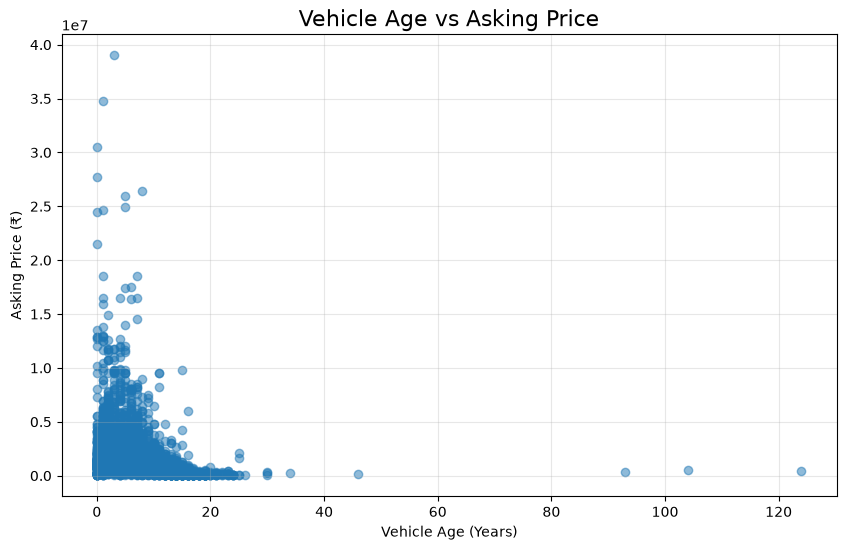

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Age"],
    df["AskPrice"],
    alpha=0.5
)

plt.title("Vehicle Age vs Asking Price", fontsize=16)
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Asking Price (₹)")

plt.grid(alpha=0.3)

plt.show()

In [12]:
correlation = df[["Age", "AskPrice"]].corr()

correlation

,Age,AskPrice
Age,1.000000,-0.281751
AskPrice,-0.281751,1.000000


In [13]:
print(f"Correlation: {df['Age'].corr(df['AskPrice']):.2f}")

Correlation: -0.28


Interpretation

The scatter plot shows that newer vehicles generally have higher asking prices, while older vehicles tend to be listed at lower prices. The correlation coefficient of -0.282 confirms a weak to moderate negative relationship between vehicle age and asking price. Although price generally decreases as vehicles age, the wide spread of points indicates that other factors such as brand, mileage, fuel type, and transmission also influence vehicle prices.

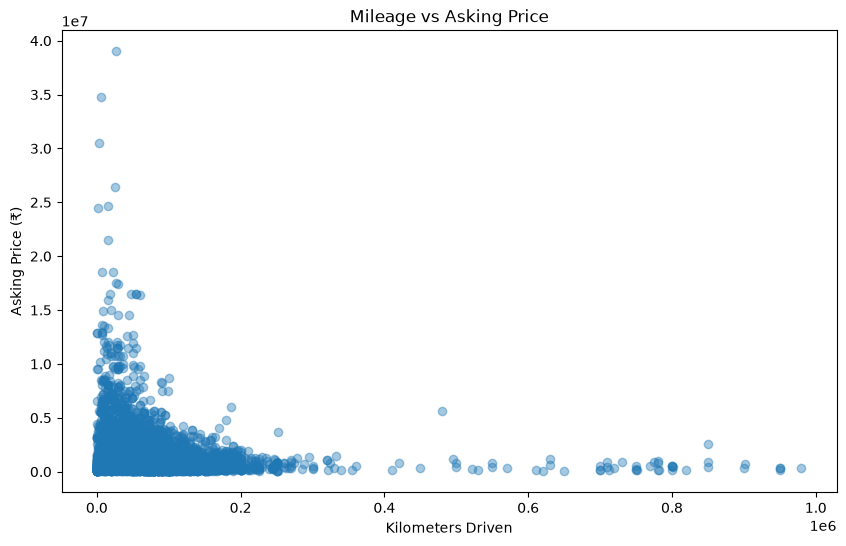

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(df["kmDriven"], df["AskPrice"], alpha=0.4)

plt.title("Mileage vs Asking Price")

plt.xlabel("Kilometers Driven")

plt.ylabel("Asking Price (₹)")

plt.show()

In [16]:
df[["kmDriven", "AskPrice"]].corr()

,kmDriven,AskPrice
kmDriven,1.000000,-0.141863
AskPrice,-0.141863,1.000000


Interpretation

The scatter plot indicates a slight downward trend between mileage and asking price. Vehicles with lower mileage generally command higher asking prices, while cars with higher mileage tend to be less expensive. The correlation coefficient of -0.142 indicates a weak negative relationship, suggesting that mileage influences vehicle prices but is not the only determining factor. Other features such as vehicle age, brand, fuel type, and transmission are also likely to contribute significantly to pricing.

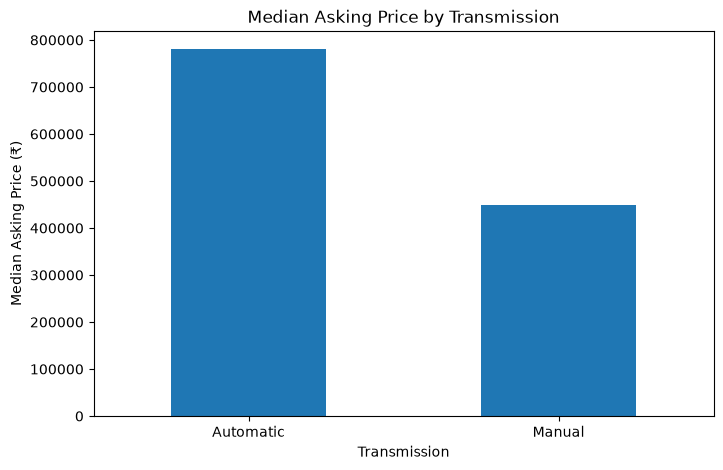

Transmission
Automatic    780000.0
Manual       450000.0
Name: AskPrice, dtype: float64

In [17]:
median_price = (
    df.groupby("Transmission")["AskPrice"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

median_price.plot(kind="bar")

plt.title("Median Asking Price by Transmission")

plt.xlabel("Transmission")

plt.ylabel("Median Asking Price (₹)")

plt.xticks(rotation=0)

plt.show()

median_price

Interpretation

The results show that vehicles with automatic transmission have a substantially higher median asking price (₹780,000) than vehicles with manual transmission (₹450,000). This suggests that automatic vehicles are generally positioned in the higher-priced segment of the used car market. The difference may reflect stronger demand for automatic vehicles, their prevalence among newer models, and their association with premium vehicle brands.

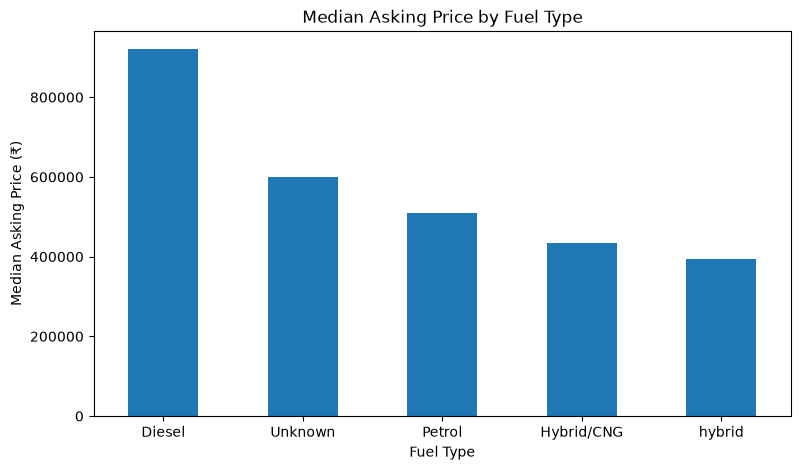

FuelType
Diesel        920000.0
Unknown       599999.0
Petrol        510000.0
Hybrid/CNG    435000.0
hybrid        395000.0
Name: AskPrice, dtype: float64

In [18]:
fuel_price = (
    df.groupby("FuelType")["AskPrice"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

fuel_price.plot(kind="bar")

plt.title("Median Asking Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Median Asking Price (₹)")

plt.xticks(rotation=0)

plt.show()

fuel_price

Interpretation.

Diesel vehicles have the highest median asking price (₹920,000), followed by vehicles with an unknown fuel type (₹600,000) and petrol vehicles (₹510,000). Hybrid/CNG and hybrid vehicles have the lowest median asking prices in this dataset. The results suggest that fuel type influences vehicle pricing, although the "Unknown" category should be interpreted cautiously because it represents missing or incomplete information rather than a true fuel type.

In [19]:
correlation = df[["Year", "Age", "kmDriven", "AskPrice"]].corr()

correlation

,Year,Age,kmDriven,AskPrice
Year,1.000000,-1.000000,-0.270199,0.277792
Age,-1.000000,1.000000,0.260750,-0.281751
kmDriven,-0.270199,0.260750,1.000000,-0.141863
AskPrice,0.277792,-0.281751,-0.141863,1.000000


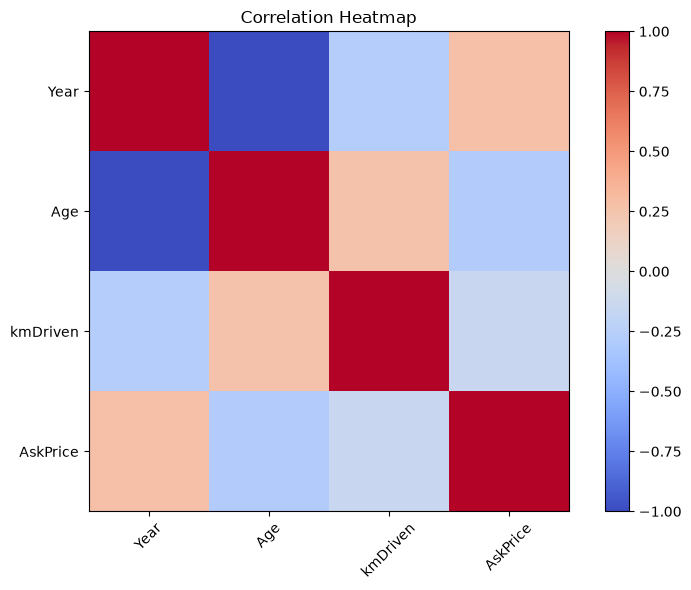

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

Interpretation

The correlation matrix reveals several important relationships between the variables. Vehicle Year has a weak positive correlation with asking price (0.278), indicating that newer vehicles generally have higher prices. Age has a weak negative correlation with asking price (-0.282), suggesting that older vehicles tend to sell for less. Kilometers Driven also shows a weak negative correlation with asking price (-0.142), meaning that vehicles with higher mileage are generally less expensive. As expected, Year and Age have an almost perfect negative correlation (-1.000) because vehicle age is directly derived from the manufacturing year.

Overall Findings

This exploratory data analysis identified several factors associated with used vehicle asking prices.

Key findings include:

The distribution of asking prices is highly right-skewed (Skewness = 8.12), indicating that most vehicles are listed within affordable price ranges while a small number of luxury vehicles command exceptionally high prices.
Brand has a significant influence on resale value. Premium manufacturers such as Porsche, Mercedes-Benz, BMW, and Land Rover consistently achieve higher median asking prices than mainstream brands.
Vehicle age shows a weak-to-moderate negative relationship with asking price (r = -0.282), confirming that newer vehicles generally sell for higher prices.
Mileage also has a negative relationship with asking price (r = -0.142), although its influence appears weaker than vehicle age.
Automatic transmission vehicles have considerably higher median asking prices than manual vehicles, suggesting higher consumer demand and association with premium vehicle models.
Diesel vehicles recorded the highest median asking prices within this dataset, although fuel type alone is unlikely to explain vehicle prices without considering additional vehicle characteristics.

Overall, the analysis demonstrates that asking price is influenced by multiple interacting factors rather than a single variable. These insights provide a strong foundation for developing predictive machine learning models in the next phase of the project.